# 9.2 案例实战 - AdaBoost信用卡精准营销模型

In [3]:
import pandas as pd
df = pd.read_excel(r"D:\1Ftostudy\商业数据分析\@Python大数据分析与机器学习商业案例实战\@Python大数据分析与机器学习商业案例实战\第9章 AdaBoost与GBDT模型\源代码汇总_Jupyer Notebook\信用卡精准营销模型.xlsx")
df.head()

,年龄,月收入（元）,月消费（元）,性别,月消费/月收入,响应
0,30,7275,6062,0,0.833265,1
1,25,17739,13648,0,0.769378,1
2,29,25736,14311,0,0.556069,1
3,23,14162,7596,0,0.536365,1
4,27,15563,12849,0,0.825612,1


In [5]:
X = df.drop(columns='响应')    # 特征变量
y = df['响应']  # 目标变量

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

## 逻辑回归模型

In [12]:
# 模型搭建 - 增加max_iter参数
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(random_state=123, max_iter=1000)
model_lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=123)

逻辑回归准确度: 0.83
逻辑回归AUC值: 0.9037737768284


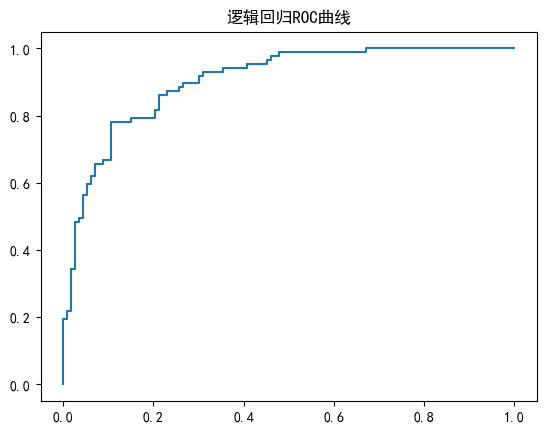

In [18]:
# 首先导入所需的评估指标
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 模型预测及评估
y_pred_lr = model_lr.predict(X_test)
y_pred_proba_lr = model_lr.predict_proba(X_test)

# 查看预测准确度
score_lr = accuracy_score(y_pred_lr, y_test)
print("逻辑回归准确度:", score_lr)

# 查看AUC值
auc_lr = roc_auc_score(y_test, y_pred_proba_lr[:,1])
print("逻辑回归AUC值:", auc_lr)

# 绘制ROC曲线
fpr_lr, tpr_lr, thres_lr = roc_curve(y_test.values, y_pred_proba_lr[:,1])
plt.plot(fpr_lr, tpr_lr)
plt.title("逻辑回归ROC曲线")
plt.show()

## 支持向量机模型

In [21]:
# 模型搭建
from sklearn.svm import SVC
model_svm = SVC(probability=True, random_state=123)
model_svm.fit(X_train, y_train)

SVC(probability=True, random_state=123)

支持向量机准确度: 0.755
支持向量机AUC值: 0.8541857389889127


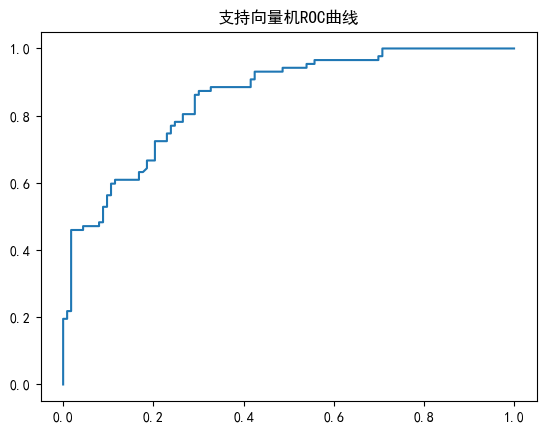

In [23]:
# 模型预测及评估
y_pred_svm = model_svm.predict(X_test)
y_pred_proba_svm = model_svm.predict_proba(X_test)

# 查看预测准确度
score_svm = accuracy_score(y_pred_svm, y_test)
print("支持向量机准确度:", score_svm)

# 查看AUC值
auc_svm = roc_auc_score(y_test, y_pred_proba_svm[:,1])
print("支持向量机AUC值:", auc_svm)

# 绘制ROC曲线
fpr_svm, tpr_svm, thres_svm = roc_curve(y_test.values, y_pred_proba_svm[:,1])
plt.plot(fpr_svm, tpr_svm)
plt.title('支持向量机ROC曲线')
plt.show()

## 随机森林模型

In [26]:
# 模型搭建
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(random_state=123)
model_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=123)

随机森林准确度: 0.84
随机森林AUC值: 0.9428338927881191
      特征名称     特征重要性
4  月消费/月收入  0.349311
2   月消费（元）  0.277845
0       年龄  0.208996
1   月收入（元）  0.139214
3       性别  0.024635


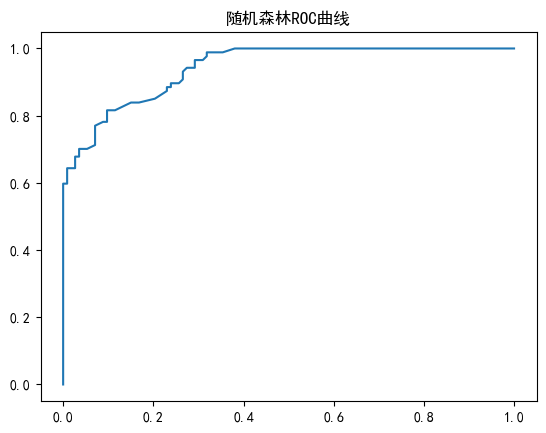

In [28]:
# 模型预测及评估
y_pred_rf = model_rf.predict(X_test)
y_pred_proba_rf = model_rf.predict_proba(X_test)

# 查看预测准确度
score_rf = accuracy_score(y_pred_rf, y_test)
print("随机森林准确度:", score_rf)

# 查看AUC值
auc_rf = roc_auc_score(y_test, y_pred_proba_rf[:,1])
print("随机森林AUC值:", auc_rf)

# 查看特征重要性
importances_rf = model_rf.feature_importances_

# 通过DataFrame的方式展示特征重要性
features = X.columns
importances_df_rf = pd.DataFrame()
importances_df_rf['特征名称'] = features
importances_df_rf['特征重要性'] = importances_rf
importances_df_rf = importances_df_rf.sort_values('特征重要性', ascending=False)
print(importances_df_rf)

# 绘制ROC曲线
fpr_rf, tpr_rf, thres_rf = roc_curve(y_test.values, y_pred_proba_rf[:,1])
plt.plot(fpr_rf, tpr_rf)
plt.title('随机森林ROC曲线')
plt.show()